# Bet Size Escalation Over Time

Weekly average bet size for the players who show the strongest loss-chasing behavior versus those who show the least. Groups are the top/bottom 10 players by loss-chasing rate (as defined in `player_Segmentation.ipynb`: the share of after-loss bets in which a player increased their bet, restricted to players with at least 10 after-loss bets).

Note: the bustabit data only spans ~6 weeks (2016-10-31 to 2016-12-10), so this shows a short-term trend rather than a full year.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from poker_coach.config import BUSTABIT_DATA_FILE, GRAPE_SODA, MUTED_TEAL

sns.set_theme(style='darkgrid')

df = pd.read_csv(BUSTABIT_DATA_FILE, na_values=['NA'], parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True)  # each player's bets in time order
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
df['BetIncreased'] = df['Bet'] > df['PrevBet']

print(f"{len(df):,} bets from {df['Username'].nunique():,} players, {df['PlayDate'].min().date()} to {df['PlayDate'].max().date()}")

50,000 bets from 4,149 players, 2016-10-31 to 2016-12-10


In [2]:
MIN_AFTER_LOSS_BETS = 10  # need enough after-loss bets for a player's chasing rate to be meaningful
N_PLAYERS = 10  # size of each comparison group

seq_df = df.dropna(subset=['PrevBet', 'PrevWon']).copy()
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})

after_loss = seq_df[seq_df['PrevOutcome'] == 'After Loss']
loss_chasing = after_loss.groupby('Username')['BetIncreased'].agg(LossChasingRate='mean', NumAfterLossBets='size')
player_stats = loss_chasing[loss_chasing['NumAfterLossBets'] >= MIN_AFTER_LOSS_BETS].dropna().reset_index()

highest_chasers = player_stats.nlargest(N_PLAYERS, 'LossChasingRate')
lowest_chasers = player_stats.nsmallest(N_PLAYERS, 'LossChasingRate')

print(f"{len(player_stats):,} players have at least {MIN_AFTER_LOSS_BETS} after-loss bets")
print(f"Highest loss-chasing group: rate >= {highest_chasers['LossChasingRate'].min():.0%}")
print(f"Lowest loss-chasing group:  rate <= {lowest_chasers['LossChasingRate'].max():.0%}")

506 players have at least 10 after-loss bets
Highest loss-chasing group: rate >= 65%
Lowest loss-chasing group:  rate <= 3%


In [3]:
df['Group'] = np.select(
    [df['Username'].isin(highest_chasers['Username']), df['Username'].isin(lowest_chasers['Username'])],
    ['Highest Loss-Chasing', 'Lowest Loss-Chasing'],
    default=None,
)
group_df = df.dropna(subset=['Group']).copy()

weekly = (
    group_df.set_index('PlayDate')
    .groupby('Group')
    .resample('W')['Bet']
    .mean()
    .rename('MeanBet')
    .reset_index()
)
weekly.head(12)

,Group,PlayDate,MeanBet
0,Highest Loss-Chasing,2016-11-06 00:00:00+00:00,198.898305
1,Highest Loss-Chasing,2016-11-13 00:00:00+00:00,764.219512
2,Highest Loss-Chasing,2016-11-20 00:00:00+00:00,852.145833
3,Highest Loss-Chasing,2016-11-27 00:00:00+00:00,304.710145
4,Highest Loss-Chasing,2016-12-04 00:00:00+00:00,1757.636364
5,Highest Loss-Chasing,2016-12-11 00:00:00+00:00,689.051282
6,Lowest Loss-Chasing,2016-11-06 00:00:00+00:00,6.441176
7,Lowest Loss-Chasing,2016-11-13 00:00:00+00:00,3.637168
8,Lowest Loss-Chasing,2016-11-20 00:00:00+00:00,4.504854
9,Lowest Loss-Chasing,2016-11-27 00:00:00+00:00,4.818182


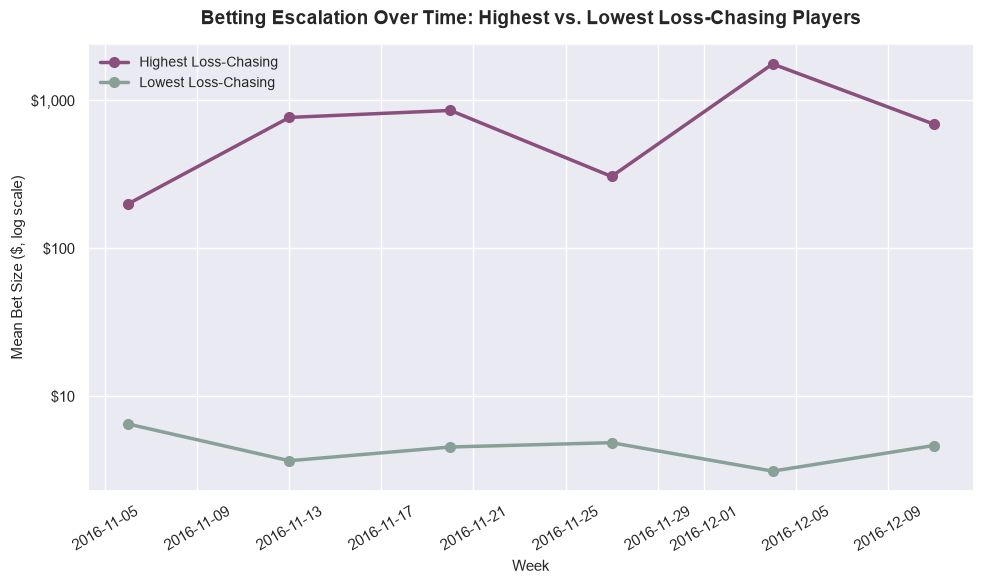

In [4]:
import matplotlib.ticker as ticker

order = ['Highest Loss-Chasing', 'Lowest Loss-Chasing']
palette = {'Highest Loss-Chasing': GRAPE_SODA, 'Lowest Loss-Chasing': MUTED_TEAL}

fig, ax = plt.subplots(figsize=(10, 6))

for group in order:
    gdf = weekly[weekly['Group'] == group]
    ax.plot(
        gdf['PlayDate'], gdf['MeanBet'], marker='o', linewidth=2.5, markersize=7,
        color=palette[group], label=group,
    )

# Log scale: the highest-chasing group's mean bet is ~2 orders of magnitude bigger
# than the lowest-chasing group's, so a linear axis flattens the lowest group to ~0.
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))

ax.set_title('Betting Escalation Over Time: Highest vs. Lowest Loss-Chasing Players', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Mean Bet Size ($, log scale)', fontsize=11)
ax.legend(frameon=False, loc='upper left', fontsize=10)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## What this chart shows

Each line is one group of 10 players, and each point is that group's **mean bet size for that calendar week**. The x-axis is time (week-ending dates from 2016-10-31 to 2016-12-10); the y-axis is dollars.

- **Highest Loss-Chasing (purple)** — the 10 players who raised their bet size most often right after a losing round (loss-chasing rate ≥ 65%). Their weekly average bet climbs from roughly 200 to a peak near 1,750, more than 8x over six weeks. The path is noisy week to week (it dips in late November before climbing again), but the overall direction is up.
- **Lowest Loss-Chasing (green)** — the 10 players who almost never raised their bet after a loss (rate ≤ 3%). Their weekly average bet stays essentially flat, hovering in the $3-7 range for the entire period.

The gap between the two lines is the point: players who exhibit loss-chasing behavior aren't just betting bigger on average — their bet sizes are actively escalating week over week, while disciplined players' bet sizes stay put. That widening, upward-trending purple line is what betting escalation looks like in practice.
